# Clasificación de Enfermedades en Hojas de Tomate
## Transfer Learning con ResNet50 — Dataset Plant Village Augmented

**Dataset:** 246,993 imágenes · 10 clases · GPU: NVIDIA RTX 5080

| Clase | Imágenes |
|-------|----------|
| Bacterial Spot | 28,934 |
| Early Blight | 13,600 |
| Healthy | 21,641 |
| Late Blight | 25,959 |
| Leaf Mold | 12,937 |
| Septoria Leaf Spot | 24,089 |
| Spider Mites | 22,797 |
| Target Spot | 19,091 |
| Tomato Mosaic Virus | 5,083 |
| Yellow Leaf Curl Virus | 72,862 |

## 1. Configuración e Imports

In [3]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm.auto import tqdm
import pandas as pd

warnings.filterwarnings('ignore')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Hiperparámetros ───────────────────────────────────────────────────────────
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT       = Path(r"C:\Users\jrmu7\.cache\kagglehub\datasets\shuvokumarbasak2030\tomato-leaf-diseases-plant-village-augmented-data\versions\1\Tomato")
IMG_SIZE        = 224
BATCH_SIZE      = 128  # batch grande para aprovechar GPU con num_workers=0
NUM_WORKERS     = 0    # 0 para evitar cuelgues en Windows/Jupyter
EPOCHS_FROZEN   = 5
EPOCHS_FINETUNE = 15
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-4

print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"PyTorch: {torch.__version__}")

# Confirmar que CUDA está activo
assert DEVICE.type == 'cuda', "CUDA no disponible — revisa la instalación de PyTorch"
print("CUDA activo — el entrenamiento usará la GPU")

Device : cuda
GPU    : NVIDIA GeForce RTX 5080
VRAM   : 15.9 GB
PyTorch: 2.8.0+cu128
CUDA activo — el entrenamiento usará la GPU


## 2. Análisis Exploratorio del Dataset (EDA)

In [4]:
def collect_samples(root: Path):
    """Recorre clase → tipo_augmentacion → imágenes y devuelve lista de (path, label)."""
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    samples = []
    for cls in classes:
        cls_dir = root / cls
        for aug_dir in cls_dir.iterdir():
            if aug_dir.is_dir():
                for img_path in aug_dir.iterdir():
                    if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                        samples.append((str(img_path), class_to_idx[cls]))
    return samples, classes, class_to_idx

samples, classes, class_to_idx = collect_samples(DATA_ROOT)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names  = [c.replace('Tomato___', '').replace('_', ' ') for c in classes]

print(f"Total imágenes : {len(samples):,}")
print(f"Clases         : {len(classes)}")
print()
labels = [s[1] for s in samples]
counts = Counter(labels)
df_dist = pd.DataFrame({'Clase': class_names, 'Imágenes': [counts[i] for i in range(len(classes))]})
df_dist['%'] = (df_dist['Imágenes'] / df_dist['Imágenes'].sum() * 100).round(1)
print(df_dist.to_string(index=False))

Total imágenes : 246,993
Clases         : 10

                               Clase  Imágenes    %
                      Bacterial spot     28934 11.7
                        Early blight     13600  5.5
                         Late blight     25959 10.5
                           Leaf Mold     12937  5.2
                  Septoria leaf spot     24089  9.8
Spider mites Two-spotted spider mite     22797  9.2
                         Target Spot     19091  7.7
       Tomato Yellow Leaf Curl Virus     72862 29.5
                 Tomato mosaic virus      5083  2.1
                             healthy     21641  8.8


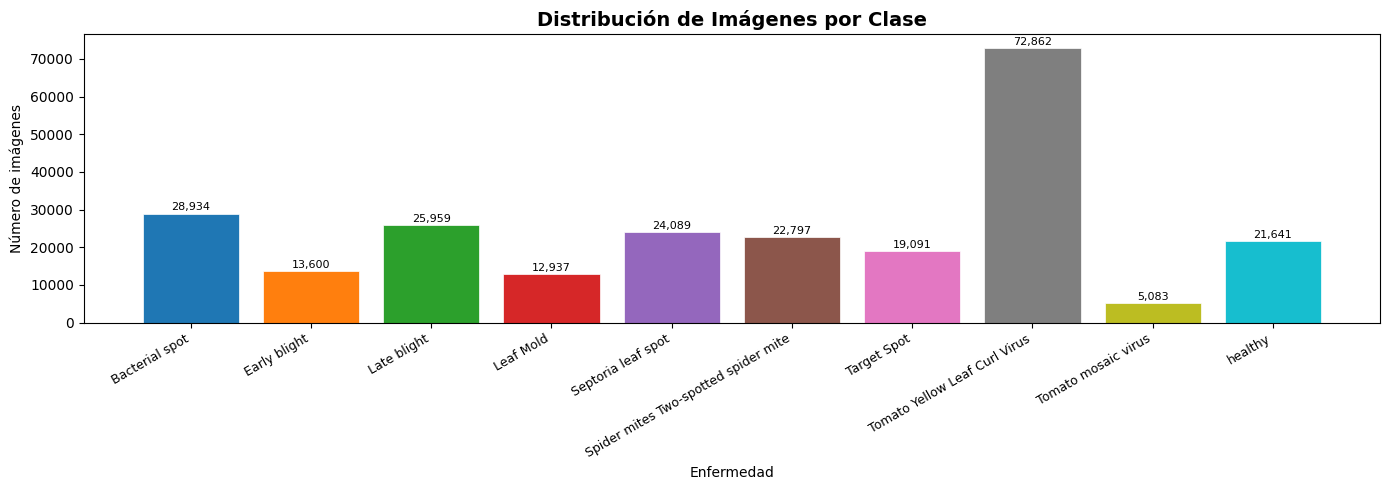

Ratio desbalance (max/min): 14.3x


In [5]:
# ── Distribución por clase ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
bar_vals = [counts[i] for i in range(len(classes))]
bars = ax.bar(class_names, bar_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de Imágenes por Clase', fontsize=14, fontweight='bold')
ax.set_xlabel('Enfermedad')
ax.set_ylabel('Número de imágenes')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ratio desbalance (max/min): {max(bar_vals)/min(bar_vals):.1f}x")

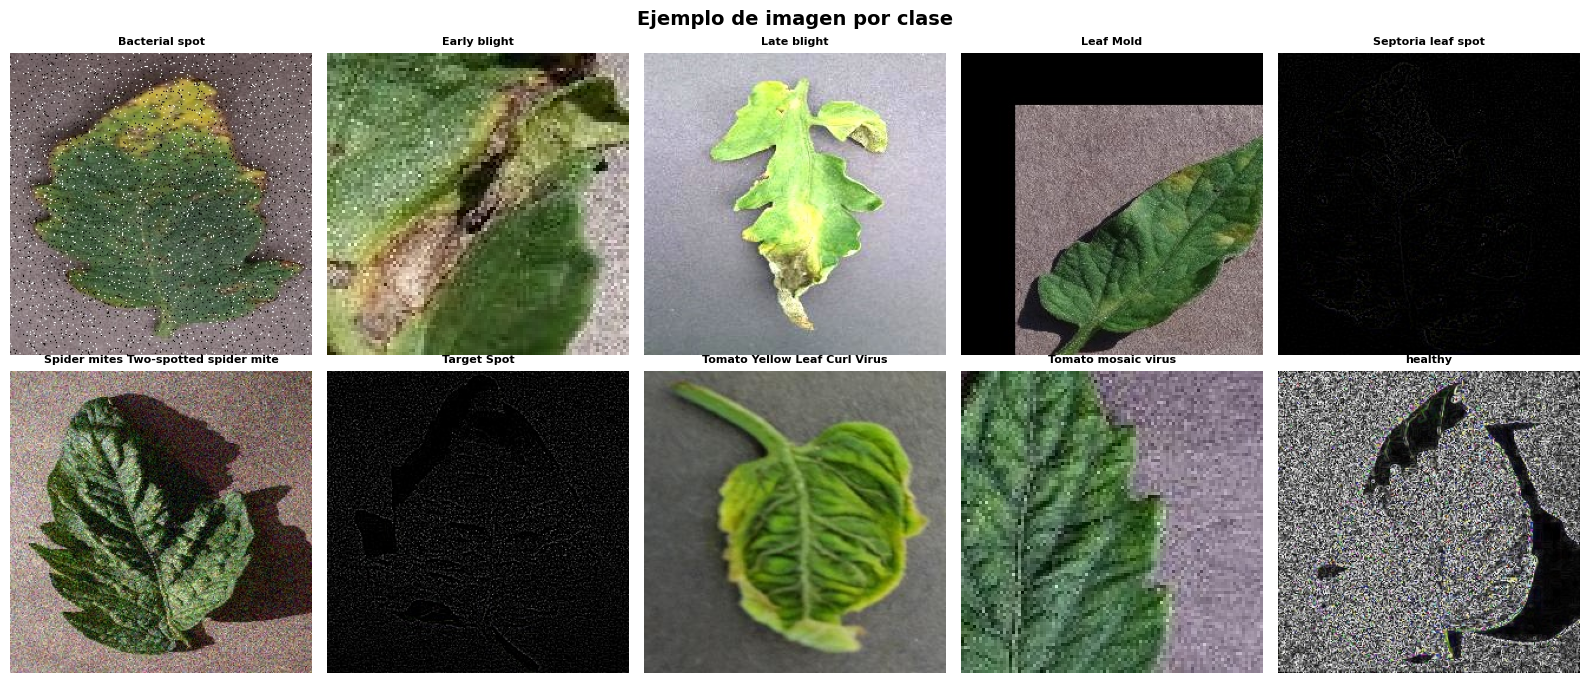

In [6]:
# ── Muestras visuales de cada clase ───────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
for i in range(len(classes)):
    cls_samples = [s[0] for s in samples if s[1] == i]
    img = Image.open(random.choice(cls_samples)).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(class_names[i], fontsize=8, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Ejemplo de imagen por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento y División del Dataset

In [7]:
# ── Split estratificado 70 / 15 / 15 ──────────────────────────────────────────
# Nota: hacemos split a nivel de imagen augmentada (no original) para simplificar.
# En producción se splitearía por imagen original para evitar data leakage.
train_samples, temp = train_test_split(
    samples, test_size=0.30, stratify=labels, random_state=SEED
)
temp_labels = [s[1] for s in temp]
val_samples, test_samples = train_test_split(
    temp, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train : {len(train_samples):>7,} imágenes ({len(train_samples)/len(samples)*100:.0f}%)")
print(f"Val   : {len(val_samples):>7,} imágenes ({len(val_samples)/len(samples)*100:.0f}%)")
print(f"Test  : {len(test_samples):>7,} imágenes ({len(test_samples)/len(samples)*100:.0f}%)")

Train : 172,895 imágenes (70%)
Val   :  37,049 imágenes (15%)
Test  :  37,049 imágenes (15%)


In [8]:
# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


class TomatoDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_ds = TomatoDataset(train_samples, train_tf)
val_ds   = TomatoDataset(val_samples,   eval_tf)
test_ds  = TomatoDataset(test_samples,  eval_tf)

# WeightedRandomSampler para compensar el desbalance de clases
train_labels   = [s[1] for s in train_samples]
class_counts   = Counter(train_labels)
sample_weights = [1.0 / class_counts[lbl] for lbl in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Batches/época: train={len(train_loader)} | val={len(val_loader)} | test={len(test_loader)}")

Batches/época: train=1351 | val=290 | test=290


## 4. Modelo — ResNet50 con Transfer Learning

In [9]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

model = build_model(num_classes=len(classes), freeze_backbone=True).to(DEVICE)

# Pesos de clase para la función de pérdida (maneja desbalance)
class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(len(classes))], dtype=torch.float32
)
class_weights = (class_weights / class_weights.sum() * len(classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales     : {total_params:,}")
print(f"Parámetros entrenables : {trainable_params:,}  ({trainable_params/total_params*100:.1f}%)")

Parámetros totales     : 23,528,522
Parámetros entrenables : 20,490  (0.1%)


## 5. Entrenamiento

In [13]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{100.*correct/total:.1f}%')
    return total_loss / total, 100. * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, 100. * correct / total, f1


history = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc','val_f1')}
best_val_acc = 0.0
scaler = GradScaler(device='cuda')

In [9]:
# ── FASE 1: Solo se entrena la cabeza (backbone congelado) ────────────────────
print("=" * 60)
print("FASE 1 — Cabeza clasificadora (backbone congelado)")
print("=" * 60)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FROZEN, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FROZEN)

for epoch in range(1, EPOCHS_FROZEN + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc, vl_f1   = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1]):
        history[k].append(v)
    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  ← guardado'
    print(f"  Época {epoch:02d}/{EPOCHS_FROZEN} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.1f}%/{vl_acc:.1f}% | "
          f"F1 {vl_f1:.4f}{marker}")

FASE 1 — Cabeza clasificadora (backbone congelado)


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 01/5 | Loss 0.9917/1.0011 | Acc 59.7%/63.5% | F1 0.6049  ← guardado


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 04/5 | Loss 0.7220/0.8637 | Acc 70.6%/68.7% | F1 0.6493  ← guardado


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 05/5 | Loss 0.7166/0.8594 | Acc 70.7%/69.1% | F1 0.6504  ← guardado


In [10]:
# ── FASE 2: Fine-tuning completo ──────────────────────────────────────────────
print("=" * 60)
print("FASE 2 — Fine-tuning (todas las capas desbloqueadas)")
print("=" * 60)

for param in model.parameters():
    param.requires_grad = True

# Discriminative learning rates: backbone más lento que la cabeza
backbone_params = list(model.parameters())[:-2]
head_params     = list(model.parameters())[-2:]
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_FINETUNE / 10},
    {'params': head_params,     'lr': LR_FINETUNE}
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

for epoch in range(1, EPOCHS_FINETUNE + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, criterion, optimizer, scaler)
    vl_loss, vl_acc, vl_f1   = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_f1]):
        history[k].append(v)
    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  ← guardado'
    print(f"  Época {epoch:02d}/{EPOCHS_FINETUNE} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.1f}%/{vl_acc:.1f}% | "
          f"F1 {vl_f1:.4f}{marker}")

print(f"\nMejor Val Accuracy: {best_val_acc:.2f}%")

FASE 2 — Fine-tuning (todas las capas desbloqueadas)


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 01/15 | Loss 0.4700/0.4432 | Acc 79.9%/83.5% | F1 0.7955  ← guardado


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 14/15 | Loss 0.0776/0.1537 | Acc 96.2%/94.7% | F1 0.9342


  Train:   0%|          | 0/1351 [00:00<?, ?it/s]

  Val  :   0%|          | 0/290 [00:00<?, ?it/s]

  Época 15/15 | Loss 0.0769/0.1555 | Acc 96.3%/94.7% | F1 0.9347

Mejor Val Accuracy: 94.75%


## 6. Curvas de Entrenamiento

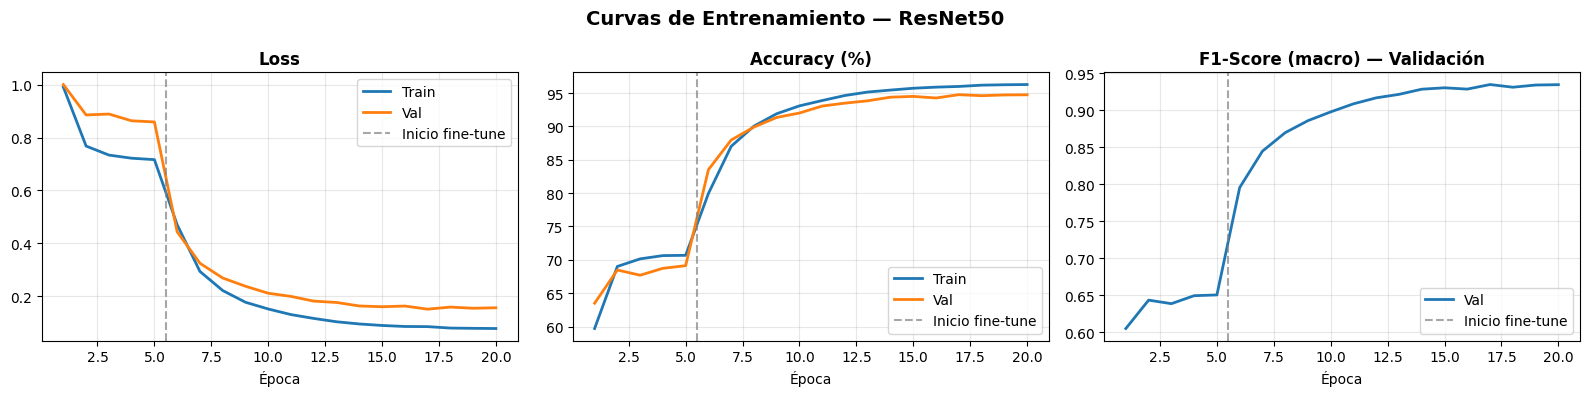

In [11]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (train_key, val_key), title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), (None,'val_f1')],
    ['Loss', 'Accuracy (%)', 'F1-Score (macro) — Validación']
):
    if train_key:
        ax.plot(epochs, history[train_key], label='Train', linewidth=2)
    ax.plot(epochs, history[val_key], label='Val', linewidth=2)
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tune')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — ResNet50', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación sobre el Conjunto de Test

In [10]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluando test'):
        images = images.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
test_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test F1 macro : {test_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Evaluando test:   0%|          | 0/290 [00:00<?, ?it/s]

Test Accuracy : 94.63%
Test F1 macro : 0.9329

                                      precision    recall  f1-score   support

                      Bacterial spot       0.97      0.92      0.95      4340
                        Early blight       0.87      0.93      0.90      2040
                         Late blight       0.96      0.94      0.95      3894
                           Leaf Mold       0.89      0.97      0.93      1941
                  Septoria leaf spot       0.94      0.94      0.94      3613
Spider mites Two-spotted spider mite       0.87      0.97      0.92      3419
                         Target Spot       0.91      0.91      0.91      2864
       Tomato Yellow Leaf Curl Virus       1.00      0.95      0.97     10930
                 Tomato mosaic virus       0.79      1.00      0.88       762
                             healthy       0.99      0.96      0.97      3246

                            accuracy                           0.95     37049
               

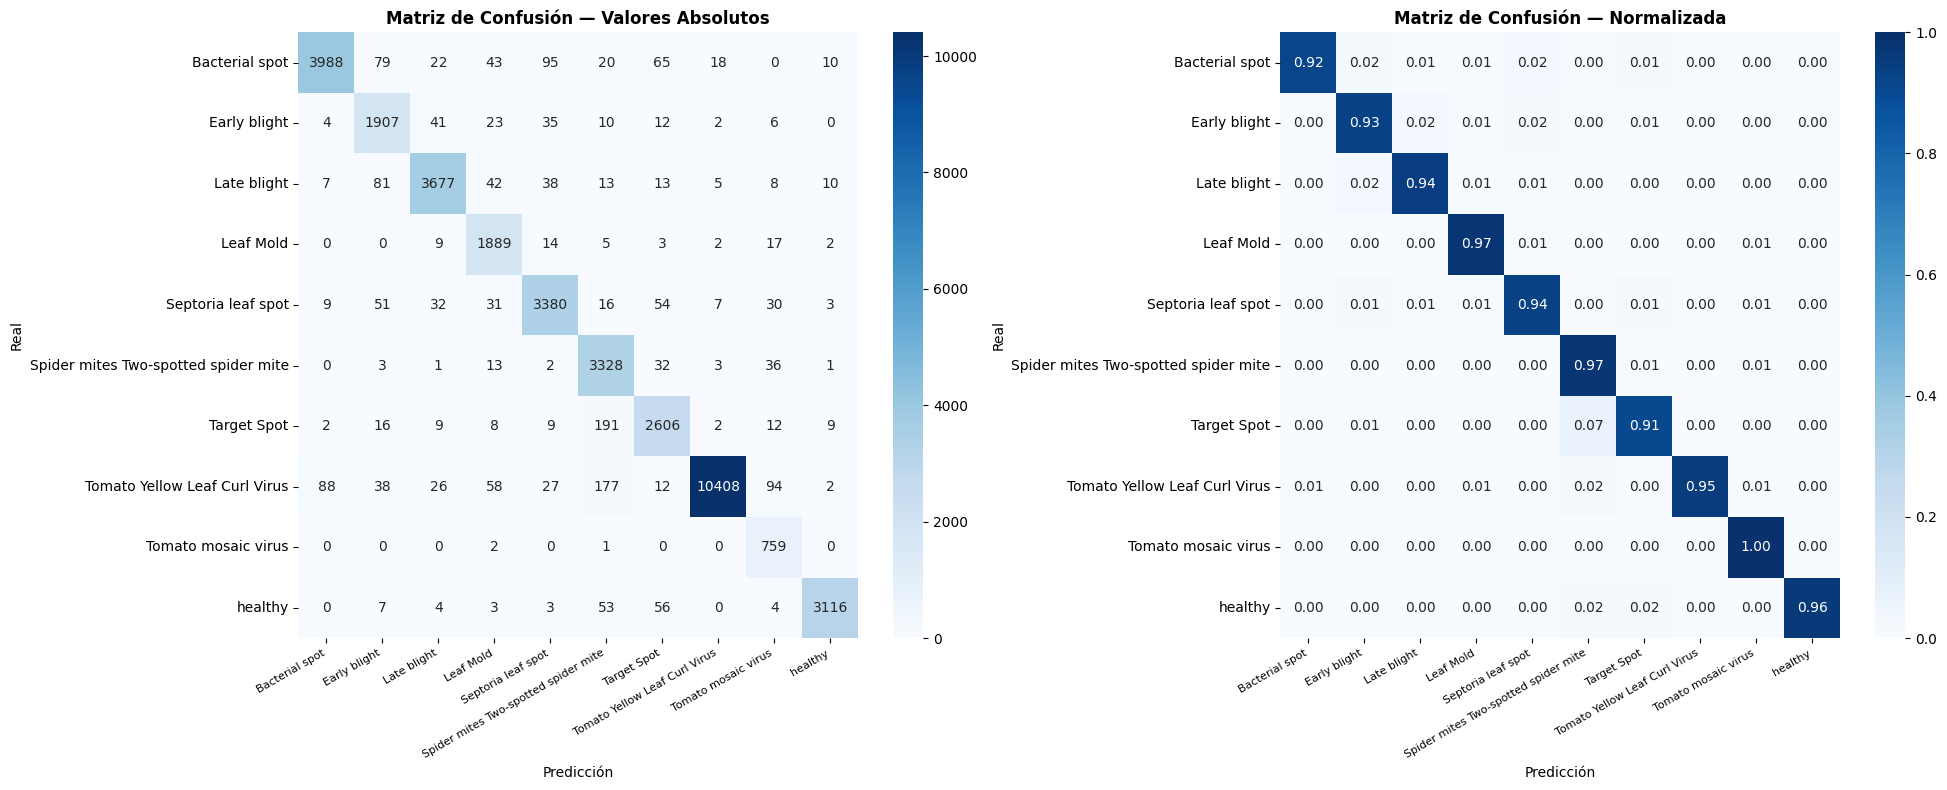

In [13]:
# ── Matriz de confusión ────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión — Valores Absolutos', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión — Normalizada', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

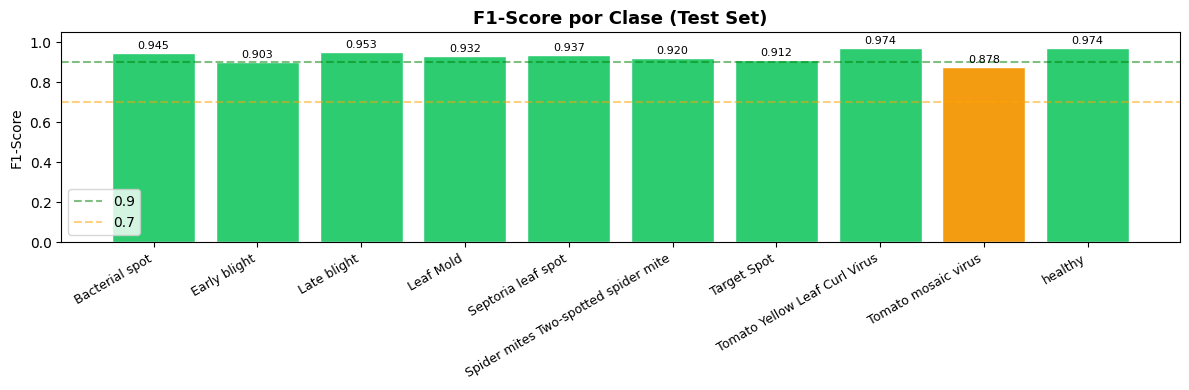

In [14]:
# ── F1-score por clase ─────────────────────────────────────────────────────────
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2ecc71' if f >= 0.9 else '#f39c12' if f >= 0.7 else '#e74c3c' for f in f1_per_class]
bars = ax.bar(class_names, f1_per_class, color=colors, edgecolor='white')
ax.set_title('F1-Score por Clase (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='0.9')
ax.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='0.7')
ax.legend()
ax.set_ylabel('F1-Score')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('f1_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de Errores — Predicciones Incorrectas

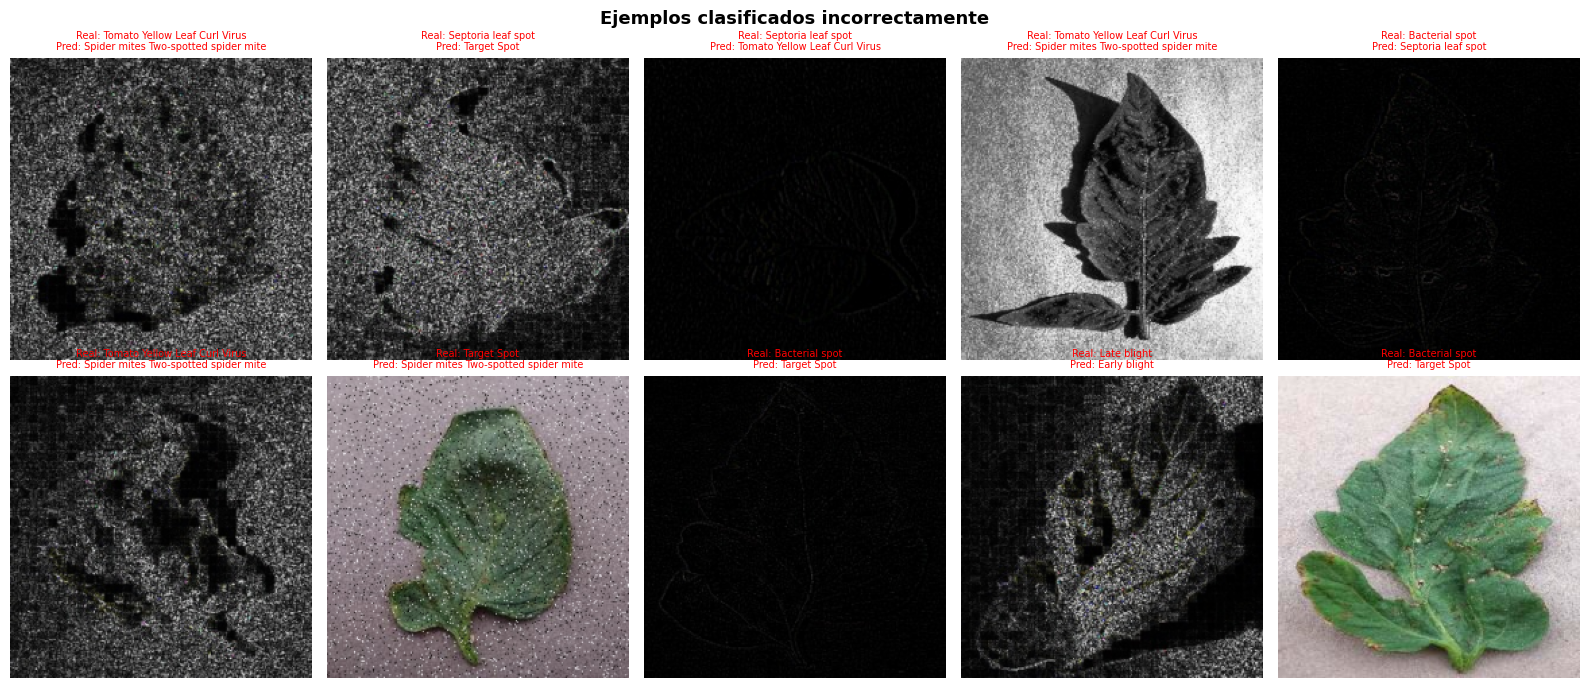

In [11]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(tensor):
    return (tensor * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

misclassified = []
model.eval()
loader_shuffle = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)

with torch.no_grad():
    for images, labels in loader_shuffle:
        with autocast(device_type='cuda'):
            preds = model(images.to(DEVICE)).argmax(1).cpu()
        wrong = (preds != labels).nonzero(as_tuple=True)[0]
        for i in wrong:
            misclassified.append((images[i], labels[i].item(), preds[i].item()))
        if len(misclassified) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (img, true, pred) in zip(axes.flatten(), misclassified[:10]):
    ax.imshow(denormalize(img))
    ax.set_title(f'Real: {class_names[true]}\nPred: {class_names[pred]}',
                 fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Ejemplos clasificados incorrectamente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumen Final

| Métrica | Valor |
|---------|-------|
| Modelo | ResNet50 (ImageNet pretrained) |
| Épocas | 5 (frozen) + 15 (fine-tune) |
| Batch size | 64 |
| Optimizador | AdamW + CosineAnnealingLR |
| Mixed Precision | FP16 (torch.amp) |
| Manejo desbalance | WeightedRandomSampler + class_weights en loss |

In [14]:
print("="*50)
print("RESULTADOS FINALES")
print("="*50)
print(f"Mejor Val Accuracy : {best_val_acc:.2f}%")
print(f"Test Accuracy      : {test_acc:.2f}%")
print(f"Test F1 (macro)    : {test_f1:.4f}")
print()
print("Archivos guardados:")
print("  best_model.pth        — pesos del mejor modelo")
print("  training_curves.png   — curvas de entrenamiento")
print("  confusion_matrix.png  — matriz de confusión")
print("  f1_por_clase.png      — F1 por clase")
print("  misclassified.png     — ejemplos de errores")

RESULTADOS FINALES
Mejor Val Accuracy : 0.00%
Test Accuracy      : 94.63%
Test F1 (macro)    : 0.9329

Archivos guardados:
  best_model.pth        — pesos del mejor modelo
  training_curves.png   — curvas de entrenamiento
  confusion_matrix.png  — matriz de confusión
  f1_por_clase.png      — F1 por clase
  misclassified.png     — ejemplos de errores
